# <img src="https://epfl-ada.github.io/assets/img/ada.svg" width="40" /> The Social Fabric They Weave

This notebook contains our analysis and its results on the Reddit dataset.

Our primary goal was to **find and demonstrate measurable links between major world events** (like a football match or an election) **and immediate behavioral shifts** inside subreddits.


In [1]:
import pandas as pd

from src.data import load_data

### The datasets

We used both the title and body datasets. In order to get additional and interesting statistics, we also used additional datasets described below.

In [2]:
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

In [3]:
df_body.head(1)

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."


In [4]:
df_title.head(1)

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,"25.0,23.0,0.76,0.0,0.44,0.12,0.12,4.0,4.0,0.0,..."


##### Subreddits embedding
The subreddits embedding dataset represents each subreddit as a 300-dimensional vector, which we can use to compute similarities and therefore cluster subreddits to analyse different groups, like sports or politics related communities.

In [5]:
df_subreddits.head(1)

,SUBREDDIT,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
0,spiders,0.158972,0.285813,0.226329,-0.183338,-0.163159,-0.18891,0.422705,0.168602,0.178193,...,-0.025041,0.184655,0.111942,-1.125799,0.223129,-0.387323,-0.234882,-0.252297,-0.054315,0.500009


##### Holidays
The holiday dataset consists of a list of all holidays in the world, grouped by their country and type.

In [6]:
df_holidays.head(1)

,ADM_name,ISO3,Date,Name,Type
44,Aruba,ABW,2014-01-01,New Year's Day,Public holiday


### Methods (POC)
We wish to implement different methods to analyze the data. Here are some proof of concepts.

This section demonstrates the feasibility of different analytical approaches before full implementation.

To preprocess the data, we wish to do the following:

1) Reduce dataset to only include active subreddits ( >100 posts as source or target) ==> Removes noise from inactive/small communities

2) Apply KNN clustering to the subreddits embeddings dataset to find similar subreddits.

3) Manually pick some clusters related to commerce.

4) Filter the subreddits (low-activity, non-English, other).

5) Provide a finished list of subreddits to be used in the analysis.

large overview of the dataframe

In [8]:
from src.preprocessing import filter_active_subreddits

active_subreddits, total_counts = filter_active_subreddits(
    body_data, 
    title_data, 
    subreddits_data, 
)

total_counts.sort_values(by='POST_COUNT_TOTAL', ascending=False)

,SUBREDDIT,POST_COUNT_BODY_SOURCE,POST_COUNT_TITLE_SOURCE,POST_COUNT_SOURCE,POST_COUNT_BODY_TARGET,POST_COUNT_TITLE_TARGET,POST_COUNT_TARGET,POST_COUNT_TOTAL
43107,subredditdrama,4665.0,22971.0,27636.0,1053.0,2454.0,3507.0,31143.0
3284,askreddit,1338.0,0.0,1338.0,7329.0,19293.0,26622.0,27960.0
5014,bestof,0.0,21170.0,21170.0,446.0,1013.0,1459.0,22629.0
21380,iama,1181.0,6.0,1187.0,3694.0,9752.0,13446.0,14633.0
34236,pics,4.0,249.0,253.0,2779.0,9799.0,12578.0,12831.0
...,...,...,...,...,...,...,...,...
24465,kickstarters,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24463,kickstand,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24461,kicks,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24460,kicklok,0.0,0.0,0.0,0.0,0.0,0.0,0.0


1300 subreddits that have:
- More than 100 posts as SOURCE (posting hyperlinks)

In [9]:
total_counts[(total_counts['POST_COUNT_SOURCE'] > 100)].sort_values(by='POST_COUNT_SOURCE', ascending=False)[['SUBREDDIT', 'POST_COUNT_BODY_SOURCE', 'POST_COUNT_TITLE_SOURCE', 'POST_COUNT_SOURCE']]

,SUBREDDIT,POST_COUNT_BODY_SOURCE,POST_COUNT_TITLE_SOURCE,POST_COUNT_SOURCE
43107,subredditdrama,4665.0,22971.0,27636.0
5014,bestof,0.0,21170.0,21170.0
45887,titlegore,3.0,9500.0,9503.0
40392,shitredditsays,501.0,7338.0,7839.0
13024,drama,1306.0,5478.0,6784.0
...,...,...,...,...
41232,smallbusiness,100.0,1.0,101.0
32782,opensource,24.0,77.0,101.0
41902,soviethistory,1.0,100.0,101.0
9035,climbing,30.0,71.0,101.0


1192 subreddits that have:
- More than 100 posts as TARGET (being mentioned)

In [10]:
total_counts[(total_counts['POST_COUNT_TARGET'] > 100)].sort_values(by='POST_COUNT_TARGET', ascending=False)[['SUBREDDIT', 'POST_COUNT_BODY_TARGET', 'POST_COUNT_TITLE_TARGET', 'POST_COUNT_TARGET']]

,SUBREDDIT,POST_COUNT_BODY_TARGET,POST_COUNT_TITLE_TARGET,POST_COUNT_TARGET
3284,askreddit,7329.0,19293.0,26622.0
21380,iama,3694.0,9752.0,13446.0
34236,pics,2779.0,9799.0,12578.0
45964,todayilearned,2371.0,8753.0,11124.0
17211,funny,2046.0,8731.0,10777.0
...,...,...,...,...
38211,rocketleagueexchange,86.0,15.0,101.0
15723,fiftyfifty,28.0,73.0,101.0
5157,beyondthebump,36.0,65.0,101.0
1172,aislingduval,33.0,68.0,101.0


778 subreddits that have:
- More than 100 posts as SOURCE (posting hyperlinks)
- AND more than 100 posts as TARGET (being mentioned)

In [11]:
total_counts[(total_counts['POST_COUNT_SOURCE'] > 100) & (total_counts['POST_COUNT_TARGET'] > 100)].sort_values(by='POST_COUNT_SOURCE', ascending=False)[['SUBREDDIT', 'POST_COUNT_SOURCE', 'POST_COUNT_TARGET', 'POST_COUNT_TOTAL']]

,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
43107,subredditdrama,27636.0,3507.0,31143.0
5014,bestof,21170.0,1459.0,22629.0
40392,shitredditsays,7839.0,924.0,8763.0
13024,drama,6784.0,988.0,7772.0
40375,shitpost,6658.0,227.0,6885.0
...,...,...,...,...
9035,climbing,101.0,292.0,393.0
34574,playrust,101.0,163.0,264.0
30702,netsec,101.0,278.0,379.0
36429,r4r,101.0,230.0,331.0


## K-Means Clustering Visualization

In [12]:
from src.clustering import reduce_dimensions_pca

embeddings_pca, pca_model = reduce_dimensions_pca(
    active_subreddits.drop(columns=['SUBREDDIT']),
    n_components=50
)
print(f"Explained variance: {pca_model.explained_variance_ratio_.sum():.2%}")

PCA explained variance ratio: 0.94
Explained variance: 94.22%


In [13]:
from src.clustering import evaluate_clustering_range

metrics_df = evaluate_clustering_range(embeddings_pca)
#metrics_df

K= 5 | Silhouette: 0.108 | Davies-Bouldin: 2.482
K=10 | Silhouette: 0.097 | Davies-Bouldin: 2.157
K=10 | Silhouette: 0.097 | Davies-Bouldin: 2.157
K=15 | Silhouette: 0.108 | Davies-Bouldin: 2.226
K=15 | Silhouette: 0.108 | Davies-Bouldin: 2.226
K=20 | Silhouette: 0.112 | Davies-Bouldin: 2.132
K=20 | Silhouette: 0.112 | Davies-Bouldin: 2.132
K=25 | Silhouette: 0.111 | Davies-Bouldin: 2.139
K=25 | Silhouette: 0.111 | Davies-Bouldin: 2.139
K=30 | Silhouette: 0.118 | Davies-Bouldin: 2.113
K=30 | Silhouette: 0.118 | Davies-Bouldin: 2.113
K=35 | Silhouette: 0.112 | Davies-Bouldin: 2.160
K=35 | Silhouette: 0.112 | Davies-Bouldin: 2.160
K=40 | Silhouette: 0.119 | Davies-Bouldin: 2.147
K=40 | Silhouette: 0.119 | Davies-Bouldin: 2.147
K=45 | Silhouette: 0.109 | Davies-Bouldin: 2.107
K=45 | Silhouette: 0.109 | Davies-Bouldin: 2.107
K=50 | Silhouette: 0.117 | Davies-Bouldin: 2.079
K=50 | Silhouette: 0.117 | Davies-Bouldin: 2.079


In [14]:
from src.clustering import perform_kmeans_clustering

cluster_labels, kmeans_model = perform_kmeans_clustering(embeddings_pca)

In [15]:
from src.clustering import reduce_to_2d_tsne
embeddings_2d = reduce_to_2d_tsne(embeddings_pca)

Reducing 50D embeddings to 2D using t-SNE...
This may take a few minutes...


In [16]:
from src.clustering import create_cluster_visualization_df
viz_df = create_cluster_visualization_df(
    embeddings_2d,
    active_subreddits['SUBREDDIT'],
    cluster_labels
)

In [17]:
from src.visualization import plot_cluster_overview
plot_cluster_overview(
    viz_df,
    #save_path='subreddit_clusters_tsne.png' TO ADD  !!!
);

ModuleNotFoundError: No module named 'src.visualization'

## KNN clustering method 2

Here we manually pick clusters related to a theme (e.g., sports) and visualize them.

In [ ]:
# Define multiple themes
THEMES = {
    'sports': ['nfl', 'nba', 'baseball', 'cfb', 'collegebasketball', 'soccer', 'sports', 'mls', 'formula1', 'reddevils'],
    'gaming': ['gaming', 'games', 'pcgaming', 'ps4', 'xboxone', 'nintendo', 'steam'],
    'politics': ['politics', 'the_donald', 'sandersforpresident', 'hillary', 'conservative', 'liberal'],
    'technology': ['technology', 'apple', 'android', 'google', 'microsoft', 'tech', 'gadgets'],
    'entertainment': ['movies', 'television', 'music', 'entertainment', 'netflix', 'marvelstudios']
}

# Pick a theme
theme = 'sports'  # Change this to explore different themes
picked_subreddits = THEMES[theme]
print(f"Analyzing theme: {theme.upper()}")
print(f"Seed subreddits: {picked_subreddits}")

Analyzing theme: SPORTS
Seed subreddits: ['nfl', 'nba', 'baseball', 'cfb', 'collegebasketball', 'soccer', 'sports', 'mls', 'formula1', 'reddevils']


In [ ]:
# Pick seed subreddits for a theme (e.g., sports)
picked_subreddits = [
    'nfl', 'nba', 'baseball', 'cfb', 'collegebasketball', 
    'soccer', 'sports', 'mls', 'formula1', 'reddevils'
]

In [ ]:
from src.similarity import similar_by_centroid

centroid_results = similar_by_centroid(
    picked_subreddits, 
    subreddits_data, 
    top_n=20
)

print("📊 Centroid-Based Similarity (average of all seeds):")
centroid_results

📊 Centroid-Based Similarity (average of all seeds):


,SUBREDDIT,SIMILARITY,ORIGINAL
23119,ncaafootball,0.860661,False
18544,ncaa,0.849401,False
10559,theb1g,0.845693,False
14955,bigeast,0.844268,False
23867,miamimls,0.833535,False
14308,acc,0.831292,False
15404,scarletknights,0.830194,False
20484,championsleague,0.827431,False
22199,sec,0.826937,False
2174,worldcup,0.817809,False


In [ ]:
from src.similarity import similar_by_max_similarity

max_sim_results = similar_by_max_similarity(
    picked_subreddits, 
    subreddits_data
)

print("\n📊 Max Similarity (closest to any seed):")
max_sim_results


📊 Max Similarity (closest to any seed):


,SUBREDDIT,MAX_SIMILARITY,CLOSEST_SEED,IS_SEED
6604,uslpro,0.960580,reddevils,False
14502,npsl,0.958882,reddevils,False
2803,ussoccer,0.949216,reddevils,False
7621,sportingkc,0.947176,reddevils,False
6570,nwsl,0.946875,reddevils,False
9370,realsaltlake,0.946160,reddevils,False
10644,dcunited,0.944229,reddevils,False
923,greenbaypackers,0.942680,baseball,False
4854,minnesotaunited,0.939800,reddevils,False
3757,acmilan,0.938837,mls,False


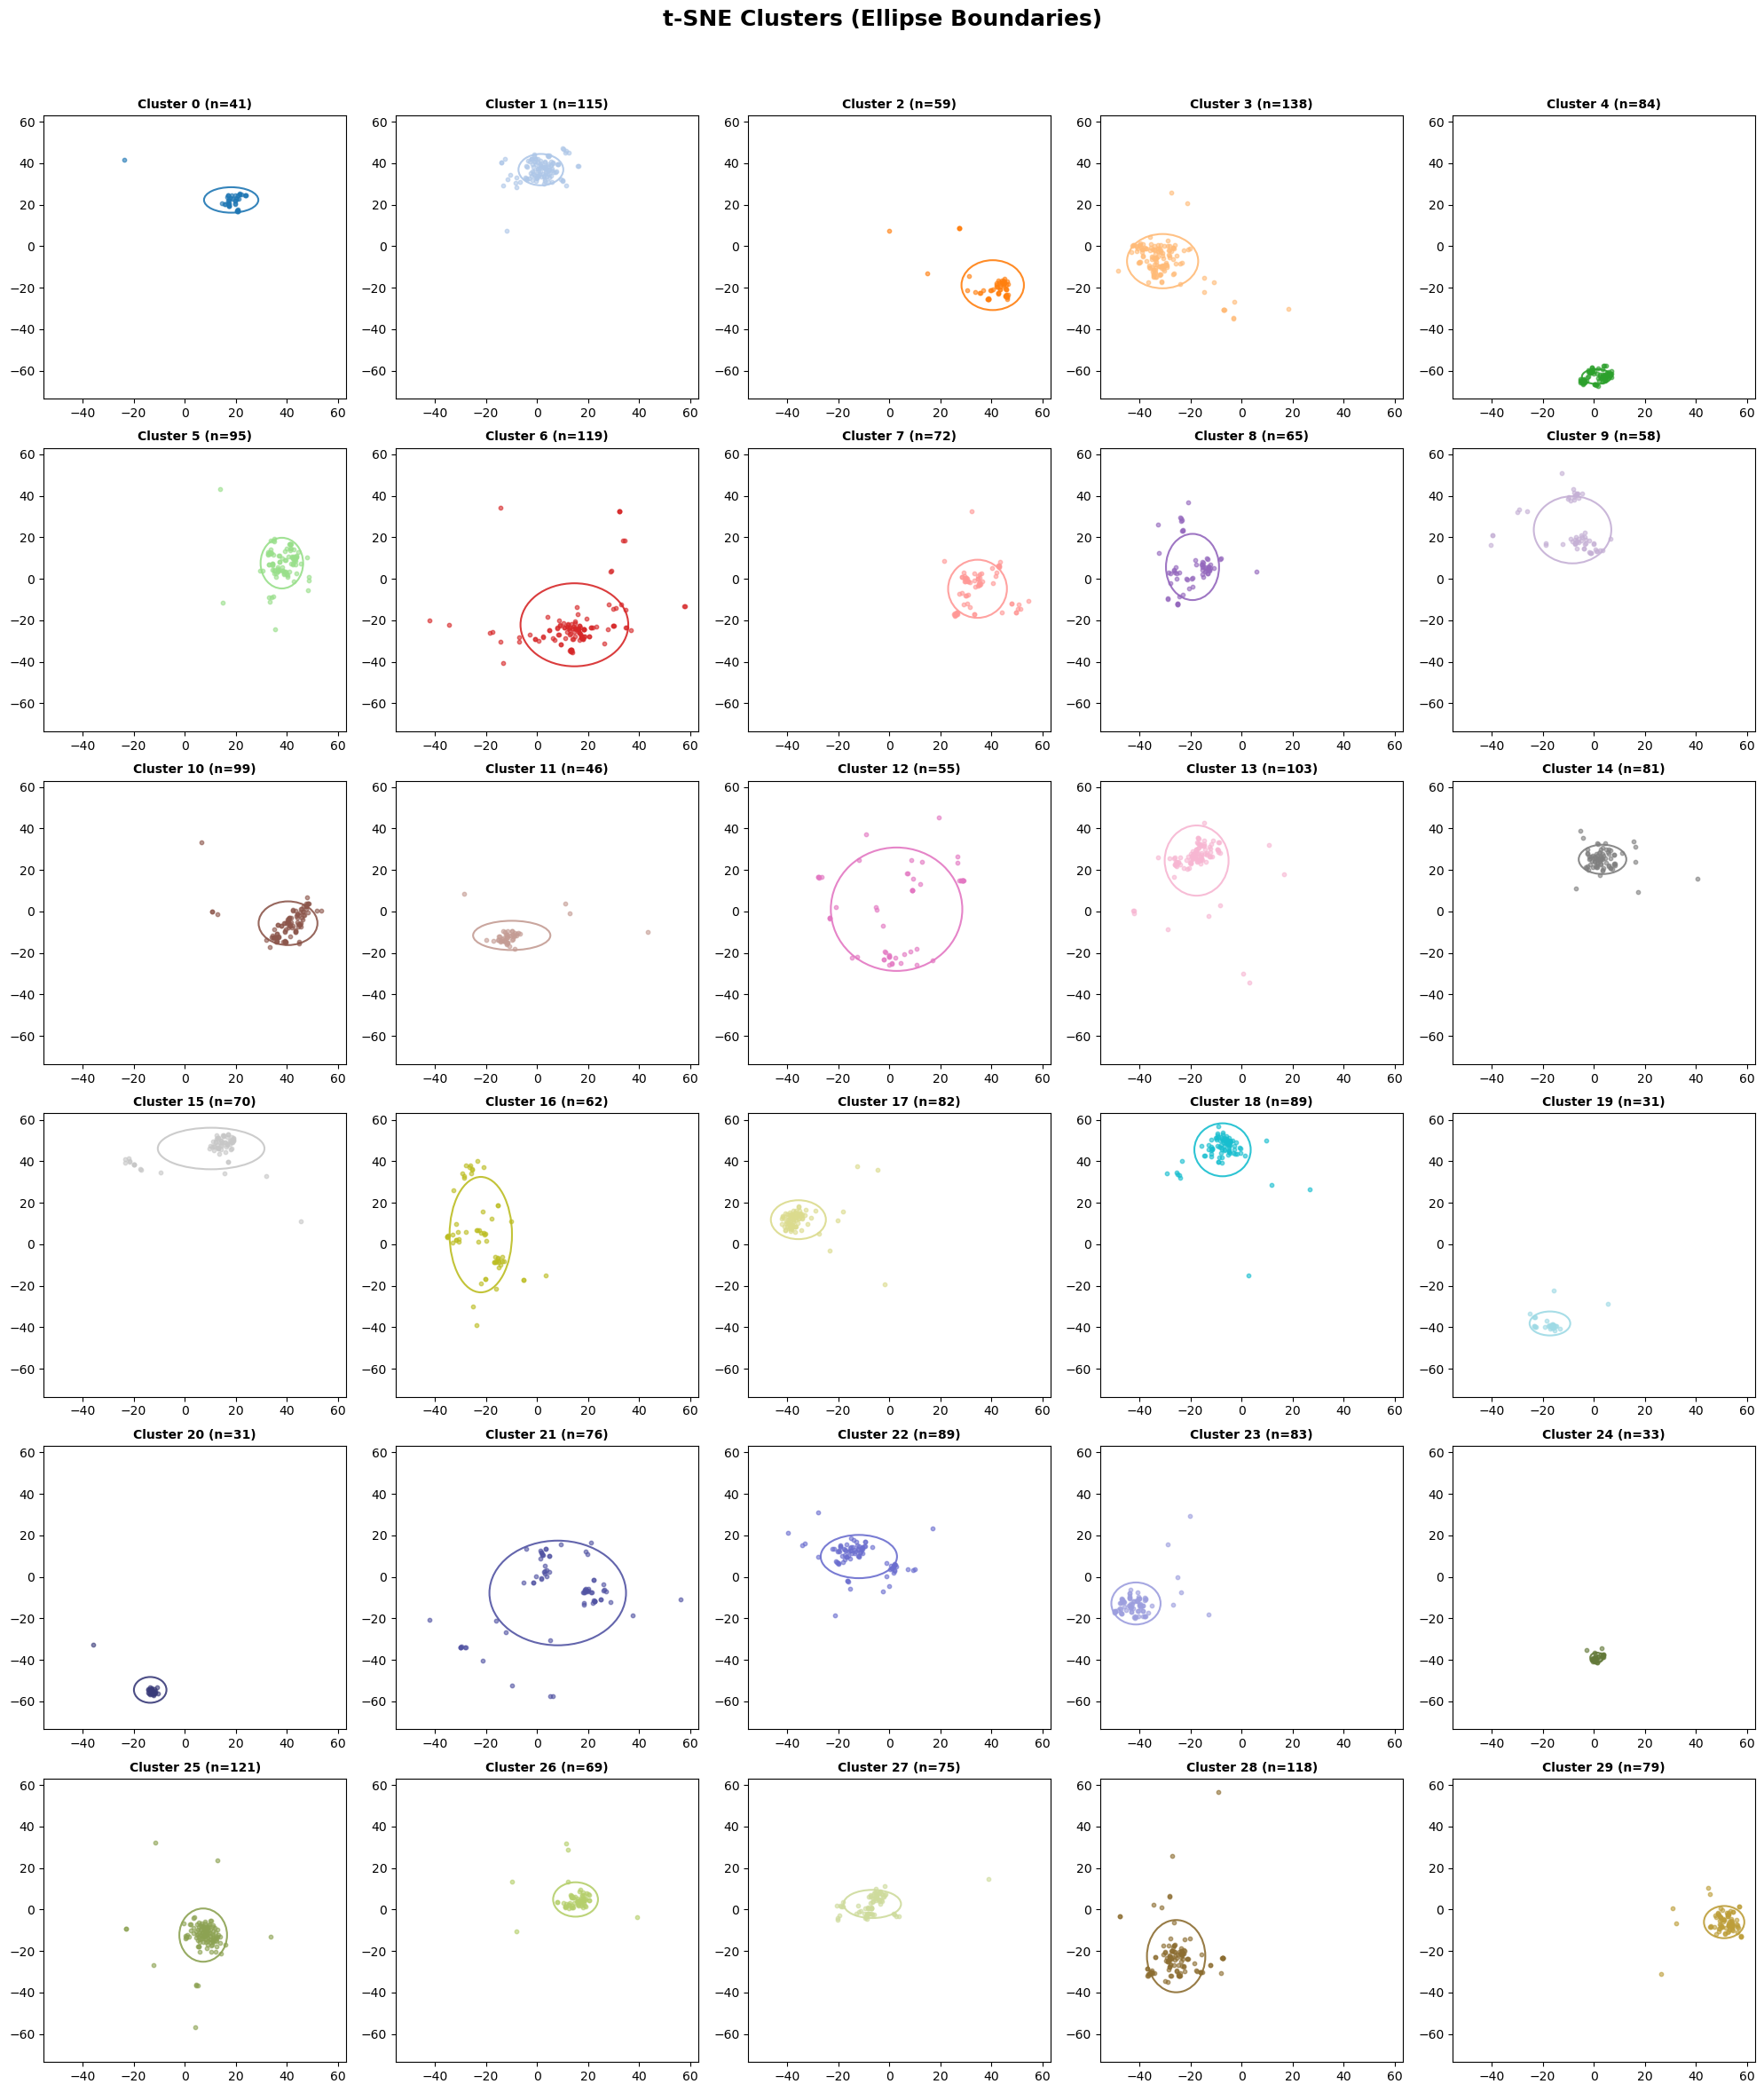

In [ ]:
from src.visualization import plot_cluster_grid

# Create cluster grid visualization
fig = plot_cluster_grid(
    viz_df,
    # save_path='cluster_grid_tsne.png'  # Uncomment to save
)


## Top active subreddits per cluster

In [ ]:
from src.consts import OPTIMAL_K

# Define columns to display
columns_show = ['SUBREDDIT', 'POST_COUNT_SOURCE', 'POST_COUNT_TARGET', 'POST_COUNT_TOTAL']

# Display top 5 active subreddits for each cluster
for cluster_id in range(OPTIMAL_K):
    # Get all subreddits in this cluster
    cluster_subreddits = viz_df[viz_df['cluster'] == cluster_id]['subreddit'].tolist()
    
    # Filter total_counts and get top 5 by total post count
    cluster_stats = (
        total_counts[total_counts['SUBREDDIT'].isin(cluster_subreddits)]
        .sort_values(by='POST_COUNT_TOTAL', ascending=False)
        .head(5)[columns_show]
    )
    
    print(f"\n{'='*60}")
    print(f"Cluster {cluster_id} - Top 5 Subreddits (n={len(cluster_subreddits)})")
    print(f"{'='*60}")
    display(cluster_stats)


Cluster 0 - Top 5 Subreddits (n=41)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
29846,music,620.0,2278.0,2898.0
20497,hiphopheads,441.0,1280.0,1721.0
13931,electronicmusic,173.0,758.0,931.0
20492,hiphopcirclejerk,768.0,30.0,798.0
13760,edmproduction,240.0,487.0,727.0



Cluster 1 - Top 5 Subreddits (n=115)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
45887,titlegore,9503.0,33.0,9536.0
40375,shitpost,6658.0,227.0,6885.0
43579,switcharoo,6039.0,3.0,6042.0
19610,hailcorporate,5360.0,263.0,5623.0
14755,evenwithcontext,2383.0,7.0,2390.0



Cluster 2 - Top 5 Subreddits (n=59)


...

,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
37550,relationships,336.0,2712.0,3048.0
46574,trees,1016.0,1693.0,2709.0
47219,twoxchromosomes,257.0,2188.0,2445.0
13169,drugs,603.0,1322.0,1925.0
11202,darknetmarkets,619.0,1095.0,1714.0



Cluster 28 - Top 5 Subreddits (n=118)

Cluster 28 - Top 5 Subreddits (n=118)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
50227,worldnews,303.0,9944.0,10247.0
14677,europe,481.0,2676.0,3157.0
22111,india,1113.0,1818.0,2931.0
7319,canada,491.0,1961.0,2452.0
47672,unitedkingdom,475.0,1438.0,1913.0



Cluster 29 - Top 5 Subreddits (n=79)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
17680,gaming,2072.0,6097.0,8169.0
17627,games,1122.0,2200.0,3322.0
17690,gamingcirclejerk,2532.0,73.0,2605.0
11975,destinythegame,558.0,1399.0,1957.0
35924,ps4,548.0,966.0,1514.0


In [ ]:
list(viz_df[viz_df['cluster'] == 2]["subreddit"]) # related to esports

['leagueoflegends',
 'globaloffensive',
 'dota2',
 'overwatch',
 'hearthstone',
 'wow',
 '2007scape',
 'smite',
 'runescape',
 'pathofexile',
 'heroesofthestorm',
 'summonerschool',
 'guildwars2',
 'h1z1',
 'starcraft',
 'playrust',
 'osugame',
 'twitch',
 'teamredditteams',
 'blackdesertonline',
 'diablo',
 'mindcrack',
 'archeage',
 'diablo3',
 'wildstar',
 'customhearthstone',
 'wowguilds',
 'learndota2',
 'csgobetting',
 'ice_poseidon',
 'competitiveoverwatch',
 'hearthstonecirclejerk',
 'wowservers',
 'clg',
 'competitivehs',
 'overwatchuniversity',
 'teamsolomid',
 'destiny',
 'livestreamfail',
 'esports',
 'forsen',
 'dota2circlejerk',
 'uhccourtroom',
 'truedota2',
 'allthingsterran',
 'dotamasterrace',
 'starcraftcirclejerk',
 'mindcrackcirclejerk',
 'leagueoflegendsmeta',
 'cloud9',
 'leagueofmeta',
 'circloljerk',
 'dota2modding',
 'dota2betting',
 'supportlol',
 'wowcirclejerk',
 'soargaming',
 'mindcrackdiscussion',
 'thecannibalcaverns']

In [ ]:
list(viz_df[viz_df['cluster'] == 19]["subreddit"]) # related to soccer

['fifa',
 'soccer',
 'sports',
 'formula1',
 'reddevils',
 'gunners',
 'cricket',
 'liverpoolfc',
 'mls',
 'boxing',
 'poker',
 'rugbyunion',
 'tennis',
 'chelseafc',
 'coys',
 'soccercirclejerk',
 'soccerstreams',
 'barca',
 'realmadrid',
 'mcfc',
 'aleague',
 'naslsoccer',
 'indycar',
 'wec',
 'footballdownload',
 'ligamx',
 'atletico',
 'uscr',
 'jleague',
 'futebol',
 'soccernerd']

# Occurrences of subreddits over time

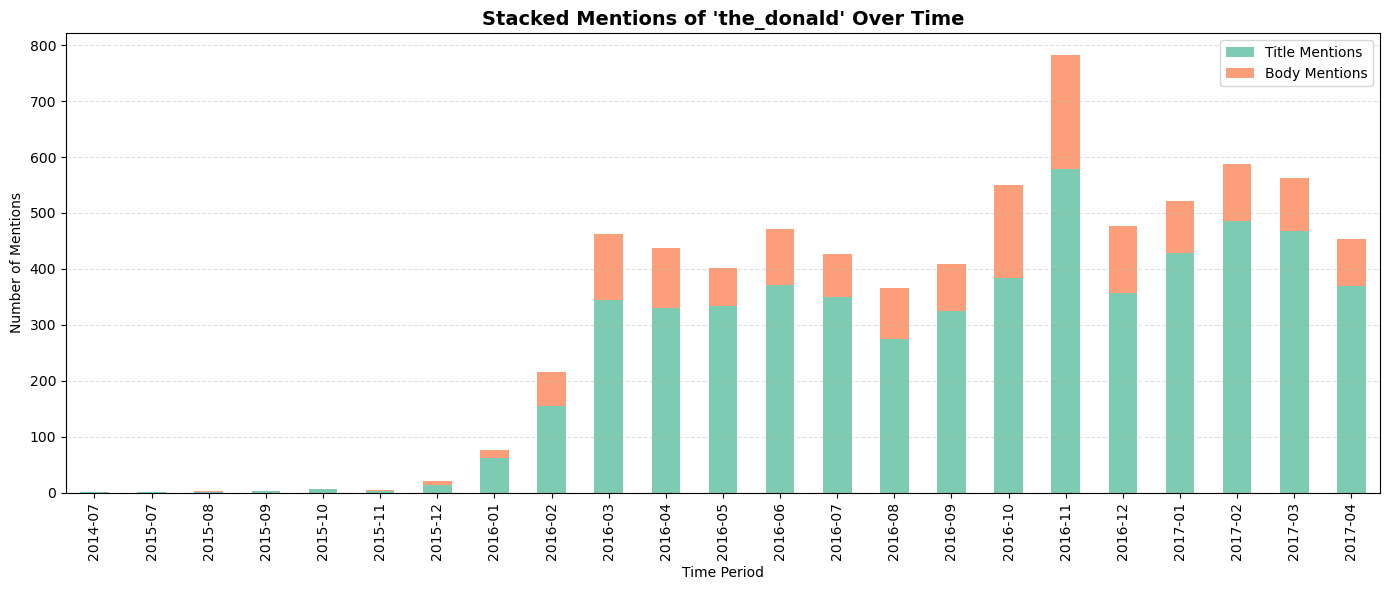

In [ ]:
from src.visualization import plot_mentions_over_time

# Choose subreddit to analyze
pattern = "the_donald"  # Options: "leagueoflegends", "dota2", "gaming", "soccer", "formula1", etc.

# Analysis parameters
period = "M"  # "M" for monthly, "W" for weekly

# Prepare data: filter mentions of the chosen subreddit
title_mentions = title_data[
    (title_data["SOURCE_SUBREDDIT"] == pattern) | 
    (title_data["TARGET_SUBREDDIT"] == pattern)
].copy()

body_mentions = body_data[
    (body_data["SOURCE_SUBREDDIT"] == pattern) | 
    (body_data["TARGET_SUBREDDIT"] == pattern)
].copy()

# Convert timestamps
title_mentions["TIMESTAMP"] = pd.to_datetime(title_mentions["TIMESTAMP"], errors="coerce")
body_mentions["TIMESTAMP"] = pd.to_datetime(body_mentions["TIMESTAMP"], errors="coerce")

# Assign period and count mentions
title_mentions["PERIOD"] = title_mentions["TIMESTAMP"].dt.to_period(period)
body_mentions["PERIOD"] = body_mentions["TIMESTAMP"].dt.to_period(period)

counts_title = title_mentions.groupby("PERIOD").size()
counts_body = body_mentions.groupby("PERIOD").size()

# Combine into DataFrame
counts_df = pd.DataFrame({
    "Title Mentions": counts_title,
    "Body Mentions": counts_body
}).fillna(0)

# Plot using the visualization function
plot_mentions_over_time(
    counts_df, 
    pattern=pattern, 
    period=period
    # save_path=f'mentions_{pattern}_over_time.png'  # Uncomment to save
);

In [ ]:
start_date = "2015-10-01"
end_date = "2015-10-31"

# Filter: subreddit match + time range
filtered_df = title_data[
    (title_data["TARGET_SUBREDDIT"] == "leagueoflegends") &
    (title_data["TIMESTAMP"].between(start_date, end_date))
]
display(filtered_df.sort_values(by='TIMESTAMP').head(5))

filtered_bf = body_data[
    (body_data["TARGET_SUBREDDIT"] == "leagueoflegends") &
    (body_data["TIMESTAMP"].between(start_date, end_date))
]

display(filtered_bf.sort_values(by='TIMESTAMP').head(5))

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES,is_relevant
257607,games,leagueoflegends,3n3dhus,2015-10-01 13:13:27,1,"85.0,72.0,0.752941176471,0.0235294117647,0.164...",False
258256,retiredgif,leagueoflegends,3n908as,2015-10-02 08:24:11,1,"58.0,51.0,0.810344827586,0.0,0.137931034483,0....",False
258184,teamsolomid,leagueoflegends,3n8gnms,2015-10-02 16:25:58,1,"36.0,30.0,0.777777777778,0.0,0.25,0.1944444444...",False
258088,datguylirik,leagueoflegends,3n7pens,2015-10-02 17:29:56,1,"71.0,63.0,0.845070422535,0.0140845070423,0.140...",False
258560,dotamasterrace,leagueoflegends,3nbsjms,2015-10-03 11:00:33,1,"52.0,45.0,0.826923076923,0.0,0.173076923077,0....",False


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES,is_relevant
129368,drama,leagueoflegends,3n4rlxs,2015-10-01 16:37:07,1,"1149.0,1021.0,0.743255004352,0.0191470844212,0...",False
131631,openbroke,leagueoflegends,3o3ujts,2015-10-01 17:27:12,1,"16980.0,16575.0,0.741048292108,0.0424028268551...",False
129449,invictusgaming,leagueoflegends,3n65vts,2015-10-02 01:26:52,1,"1903.0,1759.0,0.585391487126,0.0451918024172,0...",False
129446,cloud9,leagueoflegends,3n63css,2015-10-02 01:40:15,1,"857.0,732.0,0.752625437573,0.0210035005834,0.0...",False
129481,summonerschool,leagueoflegends,3n6n0zs,2015-10-02 03:51:57,1,"328.0,289.0,0.783536585366,0.00609756097561,0....",False


# Additional datasets

In [ ]:
events_data

,ADM_name,ISO3,Date,Name,Type
44,Aruba,ABW,2014-01-01,New Year's Day,Public holiday
45,Aruba,ABW,2014-01-25,Betico Croes' Birthday,Public holiday
46,Aruba,ABW,2014-03-03,Carnival Monday,Public holiday
47,Aruba,ABW,2014-03-18,National Anthem and Flag Day,Public holiday
48,Aruba,ABW,2014-04-18,Good Friday,Public holiday
...,...,...,...,...,...
44379,Palestine,PSE,2017-04-25,Prophet's Ascension,Public holiday
44386,Palestine,PSE,2014-01-13,Prophet's Birthday,Public holiday
44387,Palestine,PSE,2015-01-03,Prophet's Birthday,Public holiday
44388,Palestine,PSE,2015-12-24,Prophet's Birthday,Public holiday


In [ ]:
events_data.Name.value_counts()[:50]

Name
Christmas Day                         558
Good Friday                           547
Easter Monday                         467
New Year's Day                        426
Independence Day                      368
Easter Sunday                         319
New Year's Eve                        295
Valentine's Day                       208
Boxing Day                            206
Christmas Eve                         201
Labor Day / May Day                   171
Eid al-Adha                           158
Mother's Day                          158
Ascension Day                         151
Eid al-Fitr                           145
Whit Monday                           141
New Year                              140
All Saints' Day                       139
Father's Day                          136
Assumption of Mary                    131
Holy Saturday                         127
Labour Day                            126
Constitution Day                      120
International Women's Day    

In [ ]:
events_data[events_data['Name'] == 'Family Day']["ADM_name"].unique()

array(['Canada', 'Moldova', 'Mongolia', 'Mozambique', 'Namibia',
       'Ukraine', 'Vanuatu', 'South-africa'], dtype=object)

In [ ]:
# taken from https://www.kaggle.com/datasets/hbakker/esports-200-tournaments
df_esports = pd.read_csv("src/esports_tournaments_2014_2017.csv")
df_esports.head(5)

,GameID,TournamentName,StartDate,EndDate,City,Country,TeamPlay,TotalUSDPrize,year
0,5079.0,Call of Duty Championship 2014,3/28/14,3/30/14,Los Angeles,United States,1.0,1000000.0,14.0
1,6418.0,The International 2014,7/8/14,7/21/14,Seattle/Washington,United States,1.0,10931103.0,14.0
2,7376.0,LoL 2014 World Championship,9/18/14,10/19/14,Taipei/Singapore,Taiwan/Singapore,1.0,2130000.0,14.0
3,9205.0,DAC 2015,1/5/15,2/9/15,Shangai,China,1.0,3057521.0,15.0
4,8885.0,Smite World Championship 2015,1/9/15,1/1/15,Atlanta,United States,1.0,2612259.0,15.0


In [ ]:
# taken from https://www.kaggle.com/datasets/irkaal/english-premier-league-results/data98
df_epl = pd.read_csv("src/english-premier-league-results_2014-01-2017-04.csv")
df_epl.head(5)

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,2013-14,2014-01-01T00:00:00Z,Arsenal,Cardiff,2,0,H,0.0,0.0,D,...,6.0,2.0,12.0,2.0,6.0,11.0,1.0,2.0,0.0,0.0
1,2013-14,2014-01-01T00:00:00Z,Crystal Palace,Norwich,1,1,D,1.0,1.0,D,...,4.0,5.0,9.0,4.0,12.0,10.0,2.0,1.0,0.0,1.0
2,2013-14,2014-01-01T00:00:00Z,Fulham,West Ham,2,1,H,1.0,1.0,D,...,11.0,3.0,12.0,4.0,6.0,5.0,2.0,1.0,0.0,1.0
3,2013-14,2014-01-01T00:00:00Z,Liverpool,Hull,2,0,H,1.0,0.0,H,...,6.0,0.0,3.0,4.0,15.0,15.0,1.0,2.0,0.0,0.0
4,2013-14,2014-01-01T00:00:00Z,Man United,Tottenham,1,2,A,0.0,1.0,A,...,6.0,4.0,13.0,2.0,7.0,7.0,2.0,1.0,0.0,0.0


In [ ]:
# taken from https://www.kaggle.com/datasets/timoboz/superbowl-history-1967-2020
df_superbowl = pd.read_csv("src/superbowl_2014_2017.csv")
df_superbowl.head(5)

,Date,SB,Winner,Winner Pts,Loser,Loser Pts,MVP,Stadium,City,State
0,Feb 5 2017,LI (51),New England Patriots,34,Atlanta Falcons,28,Tom Brady,NRG Stadium,Houston,Texas
1,Feb 7 2016,50,Denver Broncos,24,Carolina Panthers,10,Von Miller,Levi's Stadium,Santa Clara,California
2,Feb 1 2015,XLIX (49),New England Patriots,28,Seattle Seahawks,24,Tom Brady,University of Phoenix Stadium,Glendale,Arizona
3,Feb 2 2014,XLVIII (48),Seattle Seahawks,43,Denver Broncos,8,Malcolm Smith,MetLife Stadium,East Rutherford,New Jersey
